# Ejercicio 5. Proyecciones de la red

El ejercicio 4 dejó construida la red bipartita autor-video. Este cuaderno la
proyecta sobre cada uno de sus dos conjuntos de nodos, que es la forma
habitual de pasar de una red de dos modos a una red de un modo con la que se
pueda hablar de comunidades y de centralidad.

Proyectar no es gratis y conviene decirlo antes de empezar: la proyección
**inventa** aristas que no estaban en los datos. Si cuarenta personas
comentaron el mismo video, la proyección autor-autor las une a todas con
todas, 780 aristas que nadie escribió. Ese detalle explica casi todo lo que
se ve más adelante, y por eso este cuaderno mide el efecto en vez de
ignorarlo.

Todo se reconstruye desde `src/`, de modo que los grafos de este cuaderno son
los mismos que usan los ejercicios 6 y 7 sin depender del estado del cuaderno
anterior.

In [1]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, datos, redes

warnings.filterwarnings("ignore")
config.preparar_directorios()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

videos = datos.cargar_videos()
comentarios = datos.cargar_comentarios()

B = redes.construir_bipartita(comentarios, videos)
autores = redes.nodos_por_tipo(B, redes.AUTOR)
videos_red = redes.nodos_por_tipo(B, redes.VIDEO)

print(f"Red bipartita: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")
print(f"  autores : {len(autores)}")
print(f"  videos  : {len(videos_red)}")
print(f"  comentarios que la originan: {len(comentarios)}")

Red bipartita: 351 nodos, 343 aristas
  autores : 332
  videos  : 19
  comentarios que la originan: 406


## 5.1 Proyección autor-autor

**Definición.** Dos autores se conectan si comentaron en el mismo video. El
peso de la arista es el número de videos que comparten.

Se cuenta a mano en vez de usar `nx.bipartite.weighted_projected_graph`
porque esa función devuelve como peso la similitud de Jaccard, un número
entre 0 y 1, y el enunciado pide el conteo crudo.

In [2]:
PA = redes.proyeccion_autores(B)
resumen_pa = redes.resumen(PA)

print("=== PROYECCION AUTOR-AUTOR ===")
for clave, valor in resumen_pa.items():
    print(f"  {clave:24s}: {valor:,.4f}" if isinstance(valor, float) else f"  {clave:24s}: {valor:,}")

pesos_pa = pd.Series([d["weight"] for _, _, d in PA.edges(data=True)])
print("\nDistribucion del peso (videos compartidos por par de autores):")
print(pesos_pa.value_counts().sort_index().rename("pares").to_string())

=== PROYECCION AUTOR-AUTOR ===
  nodos                   : 332
  aristas                 : 10,732
  densidad                : 0.1953
  grado_medio             : 64.6506
  grado_max               : 183
  aislados                : 4
  componentes             : 10
  componente_mayor        : 276
  componente_mayor_prop   : 0.8313
  transitividad           : 0.9840
  agrupamiento_medio      : 0.9720

Distribucion del peso (videos compartidos por par de autores):
1    10730
2        2


### Lo que hay que mirar antes de interpretar nada

La proyección tiene **10,732 aristas** construidas a partir de **343**
aristas bipartitas. Es decir, treinta y una veces más relaciones de las que
hay en los datos, y de esos 10,732 pares hay 10,730 que comparten un solo
video: sólo dos pares de autores coincidieron dos veces.

Esto no es un defecto del cálculo, es lo que significa proyectar: cada video
se convierte en un grupo completo donde todos están conectados con todos. La
consecuencia práctica es que **la densidad y la transitividad de esta red no
describen a la audiencia, describen al procedimiento**. Se calculan igual
porque el ejercicio 6 las pide, pero se leen con esa advertencia puesta.

La verificación es directa: si la red fuera exactamente la unión de un grupo
completo por video, el número de aristas sería la suma de las combinaciones
de dos autores dentro de cada video, menos los pares contados dos veces por
los autores que aparecen en más de un video.

In [3]:
autores_por_video = comentarios.groupby("video_id")["author_channel_id"].nunique()
esperadas = int((autores_por_video * (autores_por_video - 1) // 2).sum())
observadas = PA.number_of_edges()

print(f"Aristas si cada video fuera un grupo completo : {esperadas:,}")
print(f"Aristas observadas en la proyeccion           : {observadas:,}")
print(f"Diferencia (pares que dos videos comparten)   : {esperadas - observadas:,}")

autores_multi = comentarios.groupby("author_channel_id")["video_id"].nunique()
print(f"\nAutores que comentaron en mas de un video      : {(autores_multi > 1).sum()} de {len(autores_multi)}")
print(f"Proporcion                                    : {(autores_multi > 1).mean():.2%}")
print("\nReparto de autores por numero de videos distintos:")
print(autores_multi.value_counts().sort_index().rename("autores").to_string())

Aristas si cada video fuera un grupo completo : 10,734
Aristas observadas en la proyeccion           : 10,732
Diferencia (pares que dos videos comparten)   : 2

Autores que comentaron en mas de un video      : 9 de 332
Proporcion                                    : 2.71%

Reparto de autores por numero de videos distintos:
video_id
1    323
2      7
3      2


Nueve autores de 332 comentaron en más de un video. Toda la estructura no
trivial de esta red, todo lo que no sea un grupo completo aislado, sale de
esas nueve personas.

In [4]:
puentes = autores_multi[autores_multi > 1].sort_values(ascending=False)
detalle = []
for autor_id, n_videos in puentes.items():
    filas = comentarios[comentarios["author_channel_id"] == autor_id]
    detalle.append(
        {
            "autor": filas["author_name"].iloc[0],
            "videos": n_videos,
            "comentarios": len(filas),
            "canales": filas["channel_name"].nunique(),
            "grado_proyeccion": PA.degree(redes.clave_autor(autor_id)),
        }
    )

tabla_puentes = pd.DataFrame(detalle).sort_values(
    ["videos", "grado_proyeccion"], ascending=False
)
print("Los autores que conectan videos distintos:")
print(tabla_puentes.to_string(index=False))

Los autores que conectan videos distintos:
               autor  videos  comentarios  canales  grado_proyeccion
      @inge_vergueta       3            3        1               183
       @hashojea7348       3            4        1                28
        @Jel.Awesh.M       2            3        1               174
 @virgiliogarcia3039       2            3        2               145
   @moisesvaldez4043       2            2        2               133
  @MarcosCarillo-b1r       2            2        2                54
        @josegil3813       2            2        1                49
@franciscoflores3120       2            2        2                43
     @Alejandro00710       2            2        1                23


## 5.2 Proyección video-video

**Definición.** Dos videos se conectan si comparten al menos un autor. El
peso es el número de autores compartidos.

Esta es la proyección informativa de las dos. Tiene 19 nodos, se puede leer
entera, y cada arista corresponde a una persona real que efectivamente
apareció en los dos videos.

In [5]:
PV = redes.proyeccion_videos(B)
resumen_pv = redes.resumen(PV)

print("=== PROYECCION VIDEO-VIDEO ===")
for clave, valor in resumen_pv.items():
    print(f"  {clave:24s}: {valor:,.4f}" if isinstance(valor, float) else f"  {clave:24s}: {valor:,}")

aristas_pv = redes.tabla_aristas_proyeccion(PV, "video-video")
aristas_pv["canal_origen"] = aristas_pv["origen"].map(lambda n: PV.nodes[n].get("canal", ""))
aristas_pv["canal_destino"] = aristas_pv["destino"].map(lambda n: PV.nodes[n].get("canal", ""))

print(f"\nLas {len(aristas_pv)} aristas, una por una:")
vista = aristas_pv[["origen_etiqueta", "destino_etiqueta", "peso", "canal_origen", "canal_destino"]].copy()
vista["origen_etiqueta"] = vista["origen_etiqueta"].str.slice(0, 42)
vista["destino_etiqueta"] = vista["destino_etiqueta"].str.slice(0, 42)
print(vista.to_string(index=False))

=== PROYECCION VIDEO-VIDEO ===
  nodos                   : 19
  aristas                 : 11
  densidad                : 0.0643
  grado_medio             : 1.1579
  grado_max               : 4
  aislados                : 9
  componentes             : 10
  componente_mayor        : 10
  componente_mayor_prop   : 0.5263
  transitividad           : 0.3158
  agrupamiento_medio      : 0.1491

Las 11 aristas, una por una:
                           origen_etiqueta                           destino_etiqueta  peso                          canal_origen                         canal_destino
La cooptación de Walter Mazariegos en la U                  Qué rico come tu diputado     2                                Quorum                                Quorum
            Arroz con pollo a la MONOPOLIO            Internet: escoger el menos malo     2                                Quorum                                Quorum
La cooptación de Walter Mazariegos en la U Capturan a ladrón que había queda

In [6]:
aislados_pv = [n for n in PV.nodes() if PV.degree(n) == 0]
print(f"Videos aislados en la proyeccion: {len(aislados_pv)} de {PV.number_of_nodes()}\n")
tabla_aislados = pd.DataFrame(
    [
        {
            "video": PV.nodes[n]["etiqueta"][:55],
            "canal": PV.nodes[n].get("canal", ""),
            "comentarios": B.degree(n, weight="weight"),
            "autores": B.degree(n),
        }
        for n in aislados_pv
    ]
).sort_values("comentarios", ascending=False)
print(tabla_aislados.to_string(index=False))

Videos aislados en la proyeccion: 9 de 19

                                                  video                         canal  comentarios  autores
EE.UU. envía a mexicanos deportados a Guatemala antes d            Noticias Telemundo           25       18
                          Plan 2032 Ciudad de Guatemala    Municipalidad de Guatemala           25       25
I’x K’at: el primer equipo guatemalteco de pelota maya,                        Quorum            4        4
                10 Preguntas a un año del Paro Nacional                        Quorum            3        3
        Noticiero en Directo 1 pm, 28 de Agosto de 2026 Noticiero Guatevisión 13 Hrs.            2        2
                   Cruzando la ciudad a puro Transmetro                        Quorum            1        1
Edén por Salud: empleo inclusivo para personas con disc                        Quorum            1        1
          SHAI WA: la vecina queer de Casa Presidencial                        Quorum        

Un matiz que importa para no sobreinterpretar: que un video quede aislado
**no** significa que su público no vea nada más. Significa que ninguno de sus
comentaristas aparece comentando otro de los 19 videos con comentarios
recolectados. Es aislamiento dentro de la muestra, no aislamiento real. El
ejercicio 6.3 vuelve sobre esta distinción.

## 5.3 Comparación: qué fenómeno representa cada proyección

In [7]:
comparacion = pd.DataFrame(
    {
        "Bipartita autor-video": redes.resumen(B, bipartita=True),
        "Proyeccion autor-autor": resumen_pa,
        "Proyeccion video-video": resumen_pv,
    }
).T
comparacion["densidad"] = comparacion["densidad"].round(4)
comparacion["transitividad"] = comparacion["transitividad"].round(4)
comparacion["grado_medio"] = comparacion["grado_medio"].round(2)
comparacion["componente_mayor_prop"] = comparacion["componente_mayor_prop"].round(4)

print(comparacion[
    ["nodos", "aristas", "densidad", "grado_medio", "transitividad",
     "componentes", "componente_mayor", "aislados"]
].to_string())

                        nodos  aristas  densidad  grado_medio  transitividad  componentes  componente_mayor  aislados
Bipartita autor-video   351.0    343.0    0.0544         1.95         0.0000         10.0             286.0       0.0
Proyeccion autor-autor  332.0  10732.0    0.1953        64.65         0.9840         10.0             276.0       4.0
Proyeccion video-video   19.0     11.0    0.0643         1.16         0.3158         10.0              10.0       9.0


### Qué mide cada una

**La proyección autor-autor mide coincidencia de audiencia entre personas.**
Una arista dice «estas dos personas comentaron el mismo video». No dice que
se conozcan, que se hayan leído, que estén de acuerdo ni que hayan
interactuado. Con 161 comentarios en un solo video, la mayoría de estas
aristas une a dos desconocidos que escribieron con semanas de diferencia en
un hilo que ninguno de los dos volvió a abrir.

Su transitividad de 0.98 es el ejemplo de manual de una métrica que no
significa lo que parece. En una red social real, una transitividad así diría
«los amigos de mis amigos son mis amigos». Aquí dice «los grupos completos
son completos», que es una tautología: la proyección los construyó completos.

**La proyección video-video mide solapamiento de público entre contenidos.**
Una arista dice «al menos una persona comentó en los dos». Esta sí es
interpretable, porque cada arista corresponde a un individuo identificable y
el peso se puede auditar. Es la red que responde a la pregunta 3.5 sobre
audiencias compartidas.

La asimetría entre ambas es el hallazgo: la misma información produce una red
densísima de 10,732 aristas vista desde las personas y una red casi vacía de
11 aristas vista desde los contenidos. No hay contradicción. Hay mucha gente
comentando en pocos lugares y casi nadie moviéndose entre esos lugares.

In [8]:
inflacion = pd.DataFrame(
    {
        "red": ["Bipartita (observada)", "Autor-autor (proyectada)", "Video-video (proyectada)"],
        "aristas": [B.number_of_edges(), PA.number_of_edges(), PV.number_of_edges()],
    }
)
inflacion["veces_vs_bipartita"] = (inflacion["aristas"] / B.number_of_edges()).round(2)
print(inflacion.to_string(index=False))
print(
    "\nCada comentario observado sostiene "
    f"{PA.number_of_edges() / len(comentarios):.1f} aristas de la proyeccion autor-autor."
)

                     red  aristas  veces_vs_bipartita
   Bipartita (observada)      343                1.00
Autor-autor (proyectada)    10732               31.29
Video-video (proyectada)       11                0.03

Cada comentario observado sostiene 26.4 aristas de la proyeccion autor-autor.


## 5.4 Visualización de las dos proyecciones

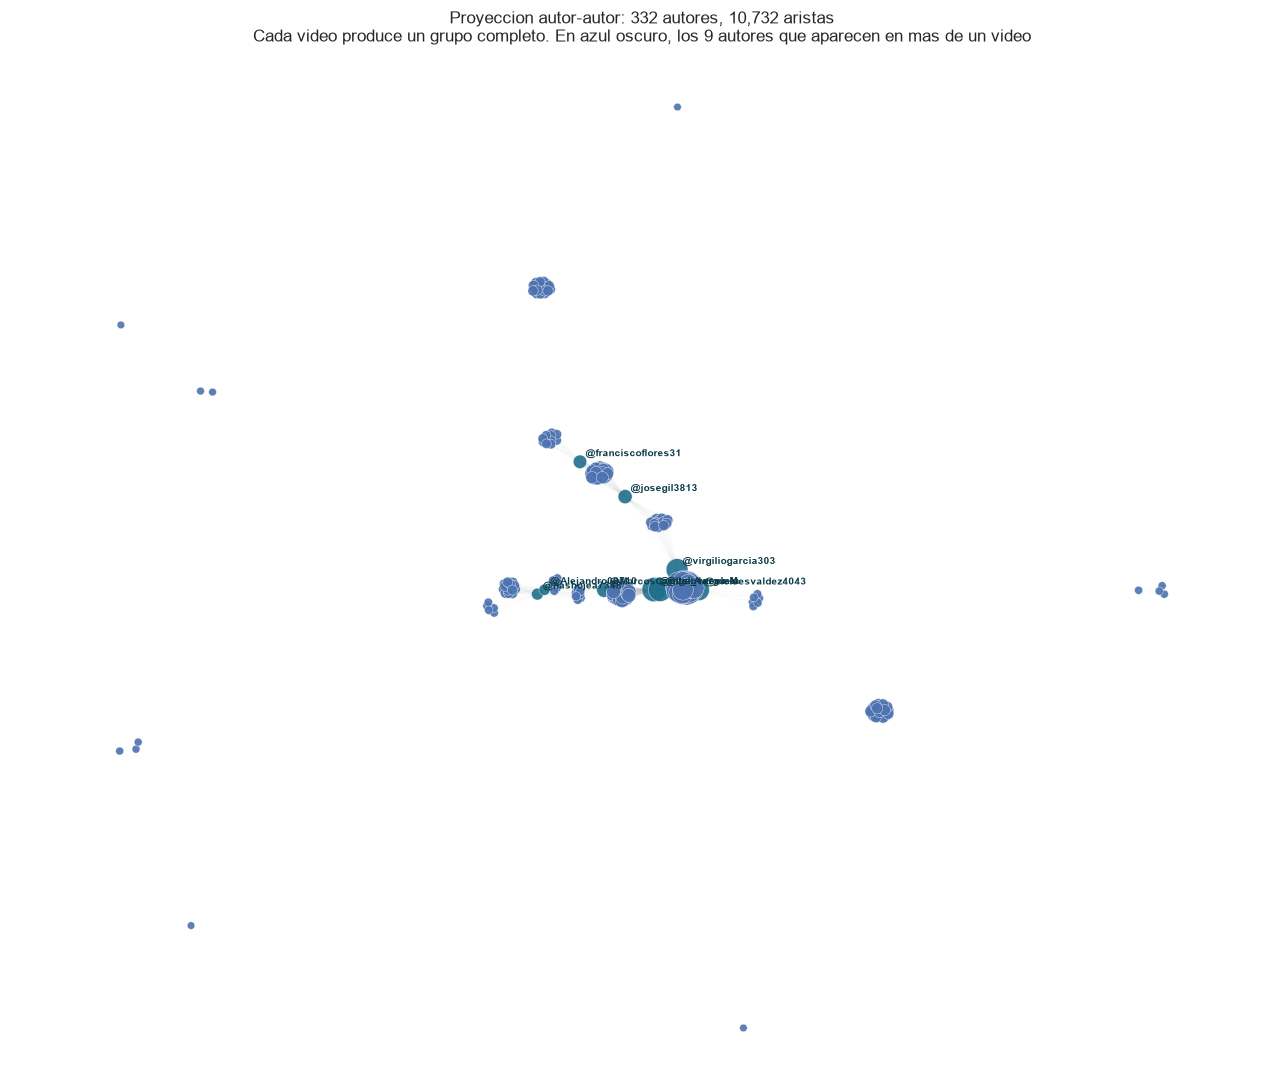

In [9]:
fig, ax = plt.subplots(figsize=(13, 11))

pos_pa = redes.disposicion(PA, semilla=config.SEMILLA)
grados_pa = dict(PA.degree())
tamanos = [30 + 1.5 * grados_pa[n] for n in PA.nodes()]
colores = [
    config.COLORES["acento"] if autores_multi.get(PA.nodes[n]["id_original"], 1) > 1
    else config.COLORES["autor"]
    for n in PA.nodes()
]

nx.draw_networkx_edges(PA, pos_pa, alpha=0.04, width=0.4, edge_color="#666666", ax=ax)
nx.draw_networkx_nodes(
    PA, pos_pa, node_size=tamanos, node_color=colores,
    linewidths=0.3, edgecolors="white", alpha=0.9, ax=ax,
)

for _, fila in tabla_puentes.iterrows():
    nodo = [n for n in PA.nodes() if PA.nodes[n]["etiqueta"] == fila["autor"]]
    if nodo:
        x, y = pos_pa[nodo[0]]
        ax.annotate(
            fila["autor"][:18], (x, y), fontsize=7.5, fontweight="bold",
            xytext=(4, 4), textcoords="offset points", color="#0b3c49",
        )

ax.set_title(
    "Proyeccion autor-autor: 332 autores, 10,732 aristas\n"
    "Cada video produce un grupo completo. En azul oscuro, los 9 autores que aparecen en mas de un video",
    fontsize=12, pad=14,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(config.FIGURAS / "05_proyeccion_autores.png", dpi=150, bbox_inches="tight")
plt.show()

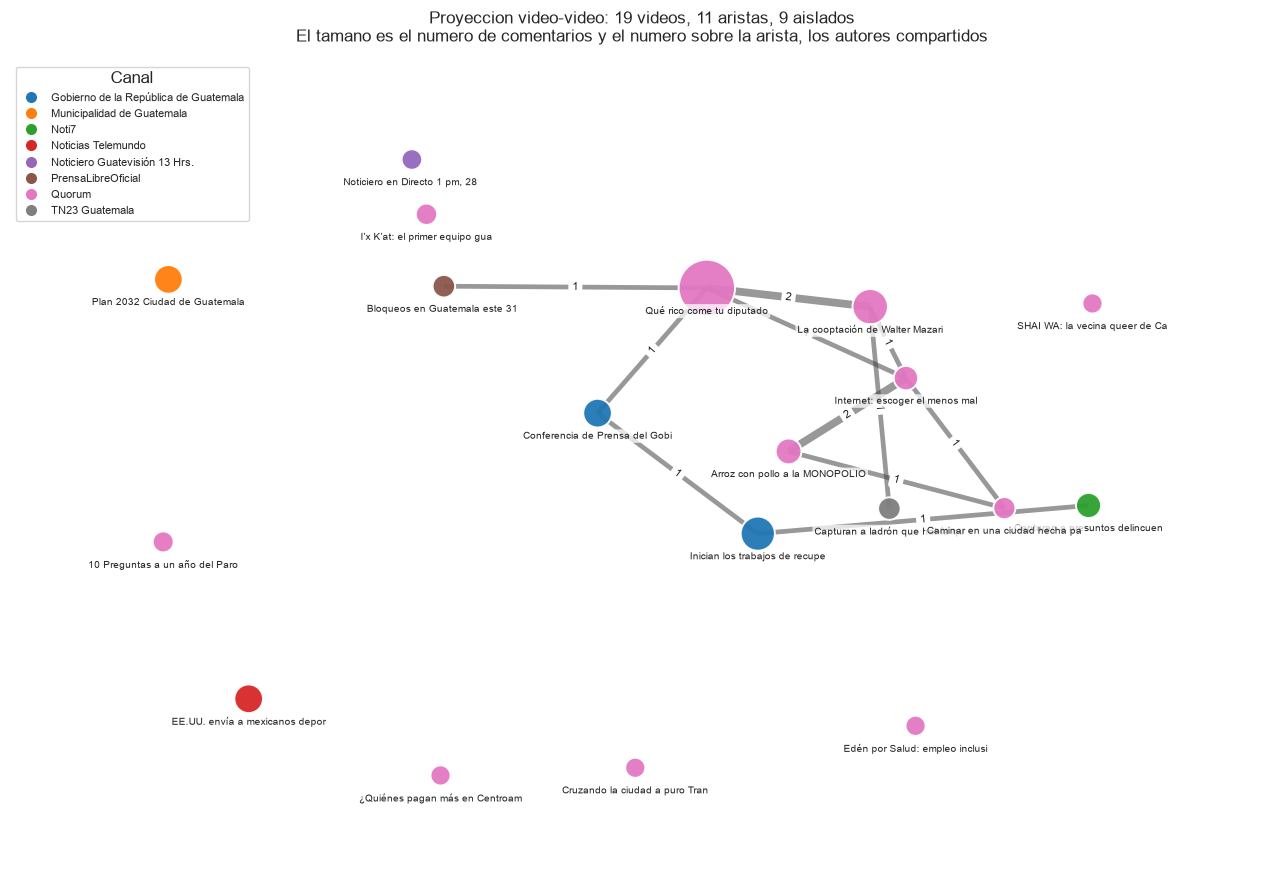

In [10]:
fig, ax = plt.subplots(figsize=(13, 9))

pos_pv = nx.spring_layout(PV, seed=config.SEMILLA, k=0.9)
comentarios_video = comentarios["video_id"].value_counts()
tamanos_pv = [200 + 9 * comentarios_video.get(PV.nodes[n]["id_original"], 0) for n in PV.nodes()]

canales = sorted({PV.nodes[n].get("canal", "") for n in PV.nodes()})
paleta = dict(zip(canales, sns.color_palette("tab10", len(canales))))
colores_pv = [paleta[PV.nodes[n].get("canal", "")] for n in PV.nodes()]

pesos_pv = [d["weight"] for _, _, d in PV.edges(data=True)]
nx.draw_networkx_edges(
    PV, pos_pv, width=[1.2 + 2.2 * w for w in pesos_pv],
    alpha=0.55, edge_color=config.COLORES["gris"], ax=ax,
)
nx.draw_networkx_nodes(
    PV, pos_pv, node_size=tamanos_pv, node_color=colores_pv,
    edgecolors="white", linewidths=1.4, alpha=0.95, ax=ax,
)
# Las etiquetas van debajo del nodo y no encima: con 19 titulos largos, un
# texto centrado sobre el circulo tapa el nodo y choca con el vecino.
for nodo, (x, y) in pos_pv.items():
    ax.annotate(
        PV.nodes[nodo]["etiqueta"][:30],
        (x, y),
        fontsize=7.5,
        ha="center",
        va="top",
        xytext=(0, -13),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75),
    )
nx.draw_networkx_edge_labels(
    PV, pos_pv, {(u, v): d["weight"] for u, v, d in PV.edges(data=True)},
    font_size=8, ax=ax,
)
ax.margins(0.16)

manejadores = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=paleta[c],
               markersize=9, label=c or "(sin canal)")
    for c in canales
]
ax.legend(handles=manejadores, loc="upper left", fontsize=8, title="Canal", frameon=True)
ax.set_title(
    "Proyeccion video-video: 19 videos, 11 aristas, 9 aislados\n"
    "El tamano es el numero de comentarios y el numero sobre la arista, los autores compartidos",
    fontsize=12, pad=14,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(config.FIGURAS / "05_proyeccion_videos.png", dpi=150, bbox_inches="tight")
plt.show()

La figura video-video se lee de un vistazo: hay un componente de diez videos
articulado alrededor de los contenidos de Quorum, y nueve videos sueltos que
no comparten a nadie con el resto. Las aristas de peso 2 son las únicas donde
dos personas distintas hicieron el mismo cruce.

## Tablas entregables

Se versionan las cuatro tablas en `processed/` para que los ejercicios 6 a 10
no tengan que reconstruir los grafos y para que el informe pueda citarlas.

In [11]:
tabla_nodos = redes.tabla_nodos(B, comentarios)
tabla_aristas_b = redes.tabla_aristas(B)
aristas_pa = redes.tabla_aristas_proyeccion(PA, "autor-autor")

tabla_nodos.to_csv(config.NODOS, index=False)
tabla_aristas_b.to_csv(config.ARISTAS, index=False)
aristas_pa.to_csv(config.ARISTAS_AUTORES, index=False)
aristas_pv.drop(columns=["canal_origen", "canal_destino"]).to_csv(
    config.ARISTAS_VIDEOS, index=False
)

for ruta in (config.NODOS, config.ARISTAS, config.ARISTAS_AUTORES, config.ARISTAS_VIDEOS):
    print(f"  {ruta.name:28s} {len(pd.read_csv(ruta)):>6,} filas")

print("\nTabla de nodos, primeras filas de cada tipo:")
print(tabla_nodos.groupby("tipo").head(3).to_string(index=False, max_colwidth=34))

  nodos_bipartita.csv             351 filas
  aristas_bipartita.csv           343 filas
  aristas_autor_autor.csv      10,732 filas
  aristas_video_video.csv          11 filas

Tabla de nodos, primeras filas de cada tipo:
                   nodo_id  tipo              id_original                           etiqueta  grado  grado_ponderado             handle                              canal       categoria   vistas  me_gusta  respuestas
a:UCi2KiZq63sRq8Mfbcp-MelQ autor UCi2KiZq63sRq8Mfbcp-MelQ                 @eugeneramirez4405      1                6 @eugeneramirez4405                                                        <NA>       1.0         0.0
a:UCyJhqmMbsvjpoarBBStA2kg autor UCyJhqmMbsvjpoarBBStA2kg                 @Murmullodelbarrio      1                6 @Murmullodelbarrio                                                        <NA>      14.0         0.0
a:UC5H8ASmMC9WrURmzeB4ySog autor UC5H8ASmMC9WrURmzeB4ySog                       @ManuelEdran      1                5       @